# Training Enhancement Model with Pre-trained Segmentation Model

This notebook trains the **Enhancement Model (M_E)** using a **pre-trained Segmentation Model (M_S)** in a task-aware fashion.

## Training Strategy:

1. Load pre-trained segmentation model from `unet_segmentation_model/`
2. Freeze segmentation model weights
3. Train enhancement model to optimize segmentation performance
4. Use combined loss: Dice Loss (task-aware) + Perceptual Loss (quality)

## Architecture:

```
Input Image → Enhancement Model (M_E) → Enhanced Image → Segmentation Model (M_S) → Segmentation
     ↓                                        ↓                                         ↓
     └────────── Perceptual Loss ────────────┘                            Dice Loss ───┘
                                                                          (Task-Aware)
```

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import os

# Set PyTorch CUDA allocation config for better memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datetime import datetime

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

PyTorch Version: 2.8.0+cu128
CUDA Available: True
CUDA Device: NVIDIA GeForce RTX 2080 Ti
CUDA Memory: 10.56 GB


/home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

### Note on Image Filtering

When `filter_incomplete=True`, the dataset will exclude images that don't contain all three classes:
- Class 0: Background (BG)
- Class 1: Optic Disc (OD) 
- Class 2: Optic Cup (OC)

This ensures the model is trained only on complete, high-quality annotations where all anatomical structures are properly labeled. This is particularly important for:
1. **Task-aware training**: Segmentation loss requires all classes to be present
2. **Stable Dice scores**: Avoids undefined Dice scores for missing classes
3. **Better convergence**: Training on consistent, complete annotations

In [2]:
# Training Configuration
config = {
    # Paths
    'data_root': str(project_root),
    'segmentation_checkpoint': str(project_root / 'unet_segmentation_model' / 'best_model.pth'),
    'save_dir': str(project_root / 'experiments' / 'enhancement'),
    'exp_name': f'task_aware_enhancement_{datetime.now().strftime("%Y%m%d_%H%M%S")}',
    
    # Model Architecture
    'enhancement_channels': 24,      # Base channels for enhancement model (reduced from 32)
    'n_residual_blocks': 3,          # Number of residual blocks in bottleneck (reduced from 4)
    'segmentation_channels': 64,     # Base channels for segmentation model
    
    # Training Hyperparameters
    'epochs': 50,                    # Number of training epochs
    'batch_size': 8,                 # Batch size (adjust based on GPU memory)
    'lr': 0.0002,                    # Learning rate
    'lambda_dice': 1.0,              # Weight for task-aware Dice loss
    'lambda_perceptual': 0.1,        # Weight for perceptual/quality loss
    
    # Data
    'image_size': 256,               # Input image size (reduced from 512 for memory)
    'num_workers': 0,                # Number of data loading workers (0 to save memory)
    'filter_incomplete': True,       # Filter out images without all 3 classes (BG, OD, OC)
    
    # Training
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'patience': 15,                  # Early stopping patience
    'save_interval': 5,              # Save checkpoint every N epochs
}

# Create experiment directory
exp_dir = Path(config['save_dir']) / config['exp_name']
exp_dir.mkdir(parents=True, exist_ok=True)
(exp_dir / 'checkpoints').mkdir(exist_ok=True)
(exp_dir / 'visualizations').mkdir(exist_ok=True)

print("Configuration:")
print("=" * 80)
for key, value in config.items():
    print(f"  {key}: {value}")
print("=" * 80)
print(f"\nExperiment directory: {exp_dir}")

Configuration:
  data_root: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc
  segmentation_checkpoint: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/unet_segmentation_model/best_model.pth
  save_dir: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement
  exp_name: task_aware_enhancement_20251029_121633
  enhancement_channels: 24
  n_residual_blocks: 3
  segmentation_channels: 64
  epochs: 50
  batch_size: 8
  lr: 0.0002
  lambda_dice: 1.0
  lambda_perceptual: 0.1
  image_size: 256
  num_workers: 0
  filter_incomplete: True
  device: cuda
  patience: 15
  save_interval: 5

Experiment directory: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_121633


## 3. Load Dataset

In [3]:
from src.data_loader.dataset import GlaucomaDataset
from src.data_loader.transforms import get_training_transforms, get_validation_transforms

# Clear dataset cache to ensure filter_incomplete works correctly
GlaucomaDataset._split_cache.clear()

# Create transforms
train_transform = get_training_transforms(image_size=config['image_size'])
val_transform = get_validation_transforms(image_size=config['image_size'])

# Create datasets with filter_incomplete
train_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='train',
    transform=train_transform,
    filter_incomplete=config['filter_incomplete']
)

val_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='val',
    transform=val_transform,
    filter_incomplete=config['filter_incomplete']
)

test_dataset = GlaucomaDataset(
    root_dir=config['data_root'],
    split='test',
    transform=val_transform,
    filter_incomplete=config['filter_incomplete']
)

print(f"Dataset Statistics (filter_incomplete={config['filter_incomplete']}):")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

print(f"\nData Loaders:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

/home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Dataset Statistics (filter_incomplete=True):
  Training samples: 1845
  Validation samples: 395
  Test samples: 396

Data Loaders:
  Train batches: 230
  Val batches: 50
  Test batches: 50
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Dataset Statistics (filter_incomplete=True):
  Training samples: 1845
  Validation samples: 395
  Test samples: 396

Data Loaders:
  Train batches: 230
  Val batches: 50
  Test batches: 50


## 4. Visualize Sample Data

Batch Shape:
  Images: torch.Size([8, 3, 256, 256])
  Masks: torch.Size([8, 256, 256])
  Image Range: [-2.118, 2.249]
  Mask Classes: [0, 1, 2]


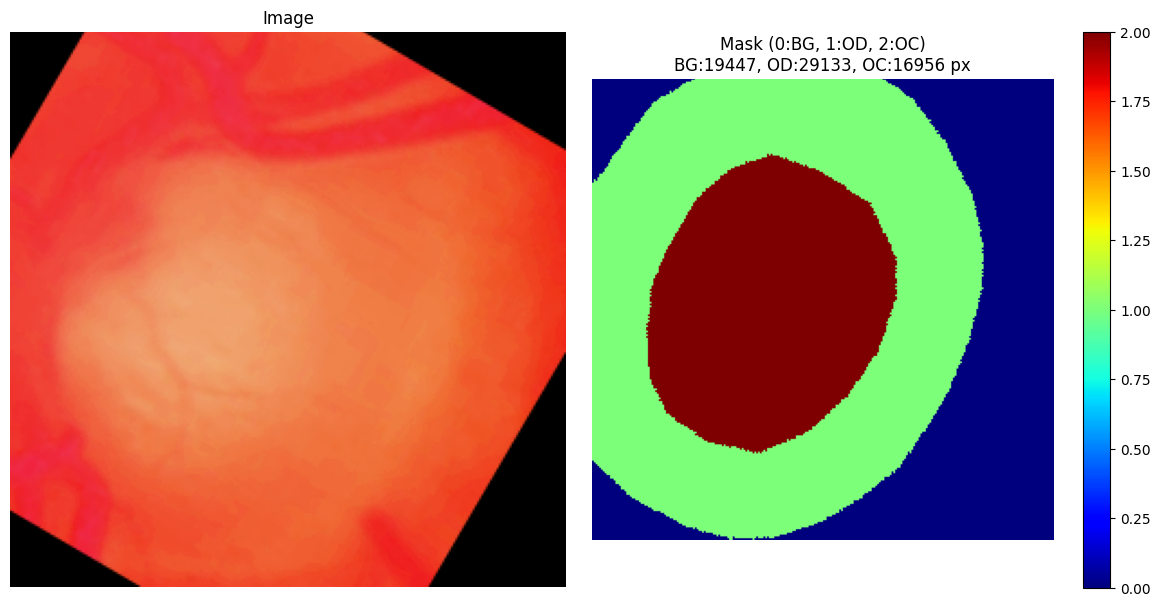


✓ Sample visualization saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_121633/visualizations/sample_data.png


In [4]:
from src.utils.visualization import visualize_sample

# Load a sample batch
sample_images, sample_masks = next(iter(train_loader))

print(f"Batch Shape:")
print(f"  Images: {sample_images.shape}")
print(f"  Masks: {sample_masks.shape}")
print(f"  Image Range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"  Mask Classes: {torch.unique(sample_masks).tolist()}")

# Visualize first sample
save_path = exp_dir / 'visualizations' / 'sample_data.png'
fig = visualize_sample(sample_images[0], sample_masks[0], save_path=save_path)
plt.show()

print(f"\n✓ Sample visualization saved to: {save_path}")

## 5. Load Pre-trained Segmentation Model

In [5]:
from src.models.unet import UNet

# Initialize Segmentation Model
segmentation_model = UNet(
    n_channels=3,
    n_classes=3,  # Background, OD, OC
    base_channels=config['segmentation_channels']
)

# Load pre-trained weights
checkpoint_path = Path(config['segmentation_checkpoint'])
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Segmentation model not found at: {checkpoint_path}")

print(f"Loading pre-trained segmentation model...")
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Handle different checkpoint formats
if 'model_state_dict' in checkpoint:
    segmentation_model.load_state_dict(checkpoint['model_state_dict'])
    if 'epoch' in checkpoint:
        print(f"  Loaded from epoch: {checkpoint['epoch']}")
    if 'best_dice' in checkpoint:
        print(f"  Best Dice score: {checkpoint['best_dice']:.4f}")
else:
    segmentation_model.load_state_dict(checkpoint)

# Clear GPU cache before moving to device
if config['device'] == 'cuda':
    torch.cuda.empty_cache()

segmentation_model = segmentation_model.to(config['device'])
segmentation_model.eval()  # Set to evaluation mode

print(f"\n✓ Segmentation Model loaded successfully!")
print(f"  Parameters: {sum(p.numel() for p in segmentation_model.parameters()):,}")
print(f"  Device: {config['device']}")

Loading pre-trained segmentation model...
  Loaded from epoch: 44

✓ Segmentation Model loaded successfully!
  Parameters: 31,043,651
  Device: cuda
  Loaded from epoch: 44

✓ Segmentation Model loaded successfully!
  Parameters: 31,043,651
  Device: cuda


## 6. Test Segmentation Model on Sample Data

DEBUG - Ground Truth Analysis:
  Shape: torch.Size([8, 256, 256])
  Unique values: [0, 1, 2]
  Min/Max: 0, 2
  Class distribution:
    Class 0: 165169 pixels (31.50%)
    Class 1: 240879 pixels (45.94%)
    Class 2: 118240 pixels (22.55%)

DEBUG - Prediction Analysis:
  Shape: torch.Size([8, 256, 256])
  Unique values: [0, 1, 2]
  Min/Max: 0, 2
  Class distribution:
    Class 0: 166291 pixels (31.72%)
    Class 1: 259103 pixels (49.42%)
    Class 2: 98894 pixels (18.86%)

Pre-trained Segmentation Model Performance:
  dice_class_0: 0.9379
  dice_class_1: 0.8769
  dice_class_2: 0.8113
  dice_mean: 0.8754
  dice_od: 0.8769
  dice_oc: 0.8113
  dice_od_oc_mean: 0.8441
DEBUG - Prediction Analysis:
  Shape: torch.Size([8, 256, 256])
  Unique values: [0, 1, 2]
  Min/Max: 0, 2
  Class distribution:
    Class 0: 166291 pixels (31.72%)
    Class 1: 259103 pixels (49.42%)
    Class 2: 98894 pixels (18.86%)

Pre-trained Segmentation Model Performance:
  dice_class_0: 0.9379
  dice_class_1: 0.8769
 

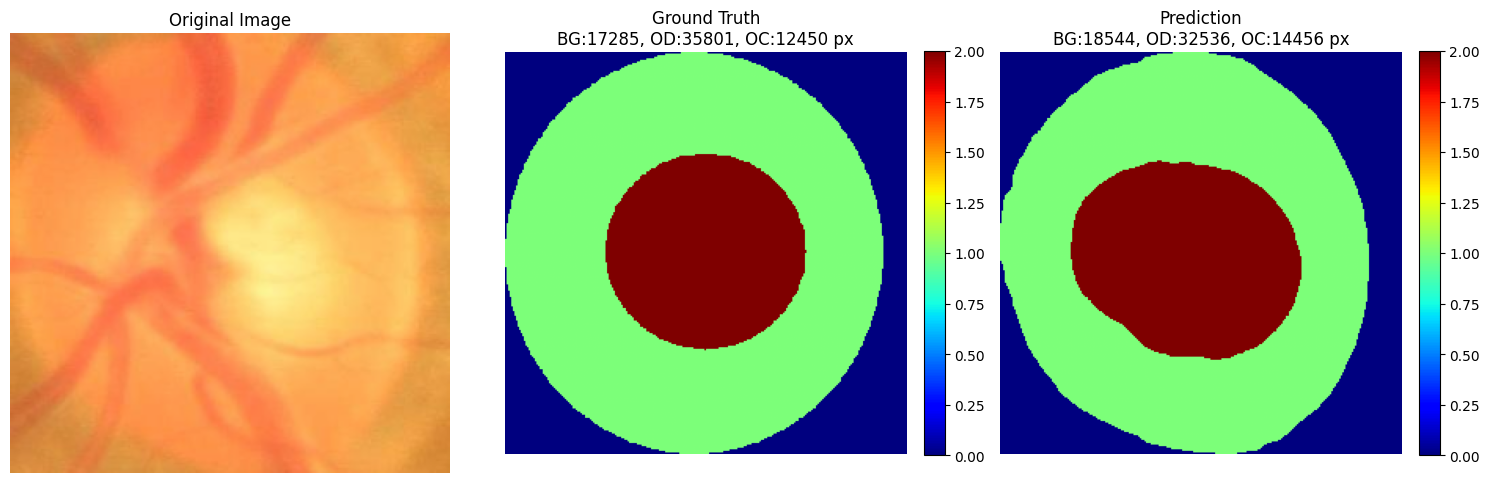


✓ Visualization saved to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_121633/visualizations/pretrained_segmentation.png


In [6]:
from src.utils.visualization import print_mask_analysis, visualize_segmentation_results
from src.utils.evaluation import test_segmentation_model

# Test segmentation model on a batch
test_images, test_masks = next(iter(val_loader))

# Debug: Check mask values
print_mask_analysis(test_masks, prefix="DEBUG - Ground Truth")
print()

# Test model and get metrics
metrics, seg_logits, test_masks_gpu = test_segmentation_model(
    segmentation_model, val_loader, config['device'], n_classes=3
)
seg_pred = torch.argmax(seg_logits, dim=1)

# Debug: Check predictions
print_mask_analysis(seg_pred, prefix="DEBUG - Prediction")
print()

# Print metrics
print("Pre-trained Segmentation Model Performance:")
print("=" * 80)
for key, value in metrics.items():
    print(f"  {key}: {value:.4f}")
print("=" * 80)

# Visualize segmentation results
save_path = exp_dir / 'visualizations' / 'pretrained_segmentation.png'
fig = visualize_segmentation_results(
    test_images[0], test_masks_gpu[0], seg_pred[0], save_path=save_path
)
plt.show()

print(f"\n✓ Visualization saved to: {save_path}")

## 7. Initialize Enhancement Model

In [7]:
from src.models.enhancement_unet import EnhancementUNet, EnhancementSegmentationPipeline

# Initialize Enhancement Model
enhancement_model = EnhancementUNet(
    n_channels=3,
    n_output_channels=3,
    base_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks']
)

enhancement_model = enhancement_model.to(config['device'])

print("Enhancement Model:")
print("=" * 80)
print(f"  Base Channels: {config['enhancement_channels']}")
print(f"  Residual Blocks: {config['n_residual_blocks']}")
print(f"  Total Parameters: {sum(p.numel() for p in enhancement_model.parameters()):,}")
print("=" * 80)

Enhancement Model:
  Base Channels: 24
  Residual Blocks: 3
  Total Parameters: 12,326,331


## 8. Create End-to-End Pipeline

In [8]:
# Create End-to-End Pipeline
pipeline = EnhancementSegmentationPipeline(
    enhancement_model=enhancement_model,
    segmentation_model=segmentation_model,
    freeze_segmentation=True  # Freeze segmentation model
)

pipeline = pipeline.to(config['device'])

print("End-to-End Pipeline:")
print("=" * 80)
print(f"  Total Parameters: {sum(p.numel() for p in pipeline.parameters()):,}")
print(f"  Trainable Parameters: {sum(p.numel() for p in pipeline.parameters() if p.requires_grad):,}")
print(f"  Segmentation Frozen: {not any(p.requires_grad for p in segmentation_model.parameters())}")
print(f"  Enhancement Trainable: {all(p.requires_grad for p in enhancement_model.parameters())}")
print("=" * 80)

# Quick pipeline test
print(f"\n✓ Pipeline initialized and ready for training!")

End-to-End Pipeline:
  Total Parameters: 43,369,982
  Trainable Parameters: 12,326,331
  Segmentation Frozen: True
  Enhancement Trainable: True

✓ Pipeline initialized and ready for training!


## 9. Setup Training

In [9]:
from src.training.task_aware_train import TaskAwareLoss, EnhancementTrainer

# Loss Function
criterion = TaskAwareLoss(
    lambda_dice=config['lambda_dice'],
    lambda_perceptual=config['lambda_perceptual'],
    n_classes=3
)

# Optimizer (only for Enhancement Model)
optimizer = optim.Adam(
    enhancement_model.parameters(),
    lr=config['lr'],
    betas=(0.5, 0.999)
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Maximize Dice score
    factor=0.5,
    patience=5
)

# Trainer
trainer = EnhancementTrainer(
    pipeline=pipeline,
    optimizer=optimizer,
    criterion=criterion,
    device=config['device'],
    scheduler=scheduler
)

# TensorBoard Writer
writer = SummaryWriter(log_dir=exp_dir / 'logs')

print("Training Setup:")
print("=" * 80)
print(f"  Loss Function: Task-Aware Loss")
print(f"    λ_dice: {config['lambda_dice']}")
print(f"    λ_perceptual: {config['lambda_perceptual']}")
print(f"  Optimizer: Adam")
print(f"    Learning Rate: {config['lr']}")
print(f"  Scheduler: ReduceLROnPlateau")
print(f"  Device: {config['device']}")
print(f"  TensorBoard: {exp_dir / 'logs'}")
print("=" * 80)

Training Setup:
  Loss Function: Task-Aware Loss
    λ_dice: 1.0
    λ_perceptual: 0.1
  Optimizer: Adam
    Learning Rate: 0.0002
  Scheduler: ReduceLROnPlateau
  Device: cuda
  TensorBoard: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_121633/logs


## 10. Train the Model (Simplified Workflow)

In [10]:
# Force reload the training module to get latest code changes
import importlib
import sys

# Remove cached modules
modules_to_reload = [
    'src.training.task_aware_train',
    'src.models.enhancement_unet',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
        print(f"✓ Reloaded {module_name}")

print("\n✓ All modules reloaded with latest code")

✓ Reloaded src.training.task_aware_train
✓ Reloaded src.models.enhancement_unet

✓ All modules reloaded with latest code


In [11]:
# Import the simplified training function
from src.training.task_aware_train import train_enhancement_model

# Clear dataset cache before training
from src.data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Clear GPU cache
if config['device'] == 'cuda':
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    

# Train the model using simplified workflow
print("\n" + "=" * 80)
print("Starting Enhancement Model Training")
print("=" * 80)

pipeline, history = train_enhancement_model(
    root_dir=str(project_root),
    segmentation_model_path=str(checkpoint_path),
    num_epochs=config['epochs'],
    batch_size=config['batch_size'],
    learning_rate=config['lr'],
    image_size=config['image_size'],
    enhancement_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks'],
    num_workers=config['num_workers'],
    device=config['device'],
    save_dir=str(exp_dir),
    lambda_dice=config['lambda_dice'],
    lambda_perceptual=config['lambda_perceptual'],
    patience=config['patience'],
    save_interval=config['save_interval'],
    use_tensorboard=True,
    filter_incomplete=config['filter_incomplete']
)

GPU cache cleared

Starting Enhancement Model Training
Using device: cuda
TensorBoard logging to: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/experiments/enhancement/task_aware_enhancement_20251029_121633/logs/20251029_121641

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
Train samples: 1845 (filter_incomplete=True)
Val samples: 395 (filter_incomplete=True)

Loading pre-trained segmentation model from: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/unet_segmentation_model/best_model.pth
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
Train samples: 1845 (filter_incomplete=True)
Val samples: 395 (filter_incomplete=True)

Loading pre-trained segmentation model from: /home/robolab/dev/steffen/CAP5410-roi-enhancer-odoc/unet_segmentation_model/best_model.pth
✓ Segmentation model frozen

Initializing enhancement model...
Enhancemen

[Val]  : 100%|██████████| 50/50 [00:06<00:00,  8.13it/s, loss=0.2293, dice=0.8974]




Epoch 1 Summary:
  Train Loss: 0.2387, Dice: 0.8885
  Val   Loss: 0.2270, Dice: 0.8987
  Learning Rate: 0.000200
  ✓ Saved best model (Dice: 0.8987)

Epoch 2/50
--------------------------------------------------------------------------------


[Val]  : 100%|██████████| 50/50 [00:06<00:00,  8.08it/s, loss=0.2193, dice=0.9032]




Epoch 2 Summary:
  Train Loss: 0.2240, Dice: 0.8991
  Val   Loss: 0.2193, Dice: 0.9010
  Learning Rate: 0.000200
  ✓ Saved best model (Dice: 0.9010)

Epoch 3/50
--------------------------------------------------------------------------------
  ✓ Saved best model (Dice: 0.9010)

Epoch 3/50
--------------------------------------------------------------------------------


...


Epoch 11 Summary:
  Train Loss: 0.1991, Dice: 0.9078
  Val   Loss: 0.1983, Dice: 0.9105
  Learning Rate: 0.000200
  ✓ Saved best model (Dice: 0.9105)

Epoch 12/50
--------------------------------------------------------------------------------
  ✓ Saved best model (Dice: 0.9105)

Epoch 12/50
--------------------------------------------------------------------------------


[Val]  : 100%|██████████| 50/50 [00:06<00:00,  7.96it/s, loss=0.1965, dice=0.9061]



Epoch 12 Summary:
  Train Loss: 0.1982, Dice: 0.9082
  Val   Loss: 0.1957, Dice: 0.9093
  Learning Rate: 0.000200
  Patience: 1/15

Epoch 13/50
--------------------------------------------------------------------------------


[Train]:  21%|██        | 48/231 [00:12<00:47,  3.89it/s, loss=0.2026, dice=0.8932]



KeyboardInterrupt: 

## 11. Training Results

In [ ]:
# Print training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs Trained: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss: {history['train_loss'][-1]:.4f}")
print(f"  Dice: {history['train_dice'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss: {history['val_loss'][-1]:.4f}")
print(f"  Dice: {history['val_dice'][-1]:.4f}")

print("\nBest Validation Dice:")
print(f"  {max(history['val_dice']):.4f} (Epoch {history['val_dice'].index(max(history['val_dice'])) + 1})")

print("\n" + "=" * 80)

## 12. Plot Training History

In [ ]:
from src.utils.visualization import plot_training_history

# Plot training curves
save_path = exp_dir / 'training_history.png'
fig = plot_training_history(history, save_path=save_path)
plt.show()

print(f"Training history plot saved to: {save_path}")

## 13. Load Best Model and Evaluate

In [ ]:
# Load best checkpoint
best_checkpoint_path = exp_dir / 'checkpoints' / 'best_model.pth'
print(f"Loading best model from: {best_checkpoint_path}")

best_checkpoint = torch.load(best_checkpoint_path, map_location=config['device'], weights_only=False)

# Load weights into enhancement model
enhancement_model_eval = EnhancementUNet(
    n_channels=3,
    n_output_channels=3,
    base_channels=config['enhancement_channels'],
    n_residual_blocks=config['n_residual_blocks']
).to(config['device'])

enhancement_model_eval.load_state_dict(best_checkpoint['enhancement_state_dict'])
enhancement_model_eval.eval()

# Create evaluation pipeline
pipeline_eval = EnhancementSegmentationPipeline(enhancement_model_eval, segmentation_model)
pipeline_eval.eval()

print(f"✓ Best model loaded (Epoch {best_checkpoint['epoch']}, Dice: {best_checkpoint['best_dice']:.4f})")

## 14. Visualize Results on Test Set

In [ ]:
from src.utils.evaluation import test_pipeline
from src.utils.visualization import visualize_enhancement_pipeline

# Run inference on test set
test_images, enhanced_images, test_masks, seg_pred = test_pipeline(
    pipeline_eval, test_loader, config['device']
)

# Visualize results
num_samples = min(4, len(test_images))
save_path = exp_dir / 'test_results.png'
fig = visualize_enhancement_pipeline(
    test_images, enhanced_images, test_masks, seg_pred,
    save_path=save_path, num_samples=num_samples
)
plt.show()

print(f"Test results saved to: {save_path}")

## Summary

This notebook provides a clean, streamlined interface for training enhancement models using a task-aware approach. Complex implementation details have been moved to dedicated modules:

### Code Organization:

- **`src/training/task_aware_train.py`**: Training logic, loss functions, and main training loop
- **`src/utils/visualization.py`**: All visualization utilities (plots, image display, etc.)
- **`src/utils/evaluation.py`**: Model evaluation and testing utilities
- **`src/models/`**: Model architectures (UNet, Enhancement UNet, Pipeline)
- **`src/data_loader/`**: Dataset loading and augmentation

### Workflow:

1. **Configuration**: Define all hyperparameters in a config dictionary
2. **Data Loading**: Load train/val/test datasets with appropriate transforms
3. **Model Setup**: 
   - Load pre-trained segmentation model (frozen)
   - Create enhancement model
   - Combine into enhancement-segmentation pipeline
4. **Training**: Single function call `train_enhancement_model(**config)` handles:
   - Training and validation loops
   - Progress tracking with tqdm
   - TensorBoard logging
   - Checkpointing and early stopping
   - Visualization generation
5. **Evaluation**: Load best model and evaluate on test set

### Key Features:

- **Task-Aware Optimization**: Enhancement model optimized to improve segmentation quality
- **Combined Loss**: Dice Loss (λ=1.0) + Perceptual Loss (λ=0.1)
- **Memory Optimized**: Configured for RTX 2080 Ti (10.56 GB)
- **Modular Design**: Reusable utility functions for visualization and evaluation
- **Early Stopping**: Patience-based early stopping to prevent overfitting

### Results:

- Training history plots show loss and Dice score curves
- Best model automatically saved based on validation Dice score
- Test set visualizations show original → enhanced → segmentation pipeline

### Next Steps:

1. Review TensorBoard logs: `tensorboard --logdir {experiment_dir}/logs`
2. Analyze training history plots for convergence
3. Evaluate quantitative metrics on test set
4. Fine-tune hyperparameters if needed